In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from input_pipeline import preprocess_dataset, batch_sampler
import baselines
from model import SpectraFormer
import xarray as xr
import jax
import numpy as np
import flax.linen as nn
import optax

### Dataset loading

In [3]:
train_ds = preprocess_dataset(xr.load_dataarray('../data/SiC_19x10x3.nc'))
test_ds = preprocess_dataset(xr.load_dataarray('../data/SiC+Graphene_50x20.nc'))

dummy_example = next(batch_sampler(train_ds, batch_size=1))
print("Data batch shapes:")
for k, v in dummy_example.items():
    print(f"  {k} -> {v.shape}")

Data batch shapes:
  spectra -> (1, 1015, 1)
  masked_spectra -> (1, 1015, 1)
  wave_number -> (1015, 1)
  mask -> (1015,)


### Model loading

In [4]:
from pathlib import Path
from inference import predict, plot_results
import orbax.checkpoint as ocp
checkpointer = ocp.StandardCheckpointer()
ckpt_dir = Path('../checkpoints').resolve()
test_batch = next(batch_sampler(test_ds, batch_size=1))

In [5]:
median_baseline_variables = checkpointer.restore(ckpt_dir / 'median/100x10')
baseline_predictions = predict(baselines.median, median_baseline_variables, test_batch)
for k, v in baseline_predictions.items():
    print(f"  {k} -> {v.shape}")

  spectra -> (1015,)
  masked_spectra -> (1015,)
  wave_number -> (1015,)
  mask -> (1015,)
  predicted_spectra -> (1015,)
  predicted_difference -> (1015,)


Text(0.5, 1.0, 'Median Baseline')

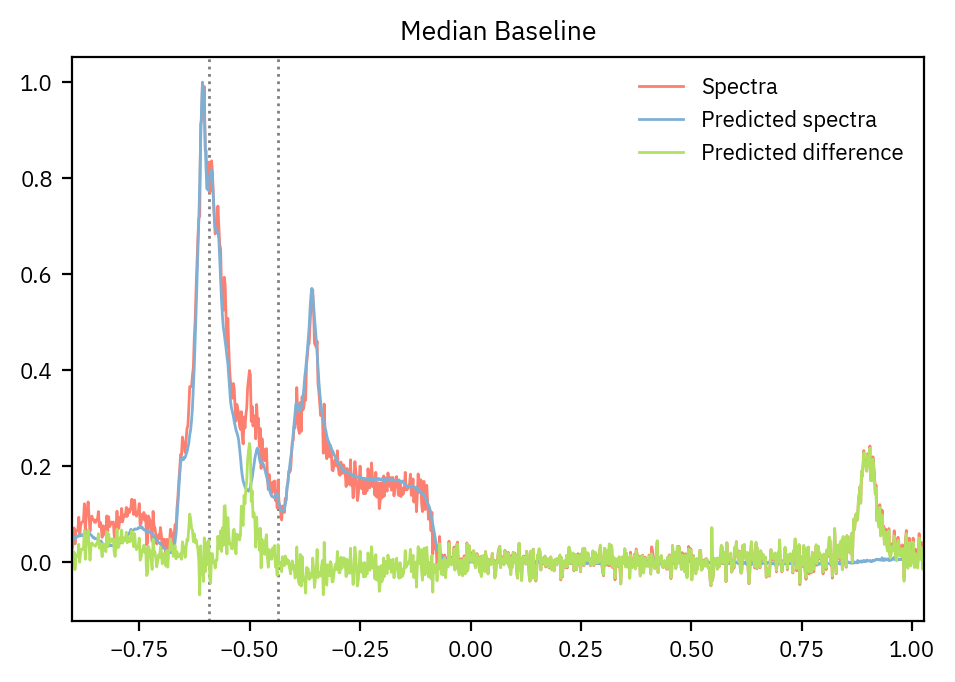

In [6]:
fig, ax = plot_results(baseline_predictions)
ax.set_title('Median Baseline')

In [39]:
from flax.training.train_state import TrainState

model = SpectraFormer(embedding_dim = 32, num_heads = 4, num_layers = 4)
root_key = jax.random.key(seed=0)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

variables = model.init(params_key, dummy_example['masked_spectra'][0], dummy_example['wave_number'], dummy_example['mask'], training = False)
params = variables['params']

state = TrainState.create(
  apply_fn=jax.jit(model.apply, static_argnames=('training', 'capture_intermediates')),
  params=params,
  tx=optax.adam(1e-4)
)
state = checkpointer.restore(ckpt_dir / 'spectraformer/20Feb24', state)

FileNotFoundError: Checkpoint at /home/novelli/SpectraFormer/checkpoints/spectraformer/20Feb24 not found.

In [40]:
tabulate_fn = nn.tabulate(model, jax.random.key(0), depth = 1, console_kwargs={'force_jupyter': True})
print(tabulate_fn(dummy_example['masked_spectra'][0], dummy_example['wave_number'], dummy_example['mask'], training = False))

                                               SpectraFormer Summary                                               
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module                ┃ inputs                ┃ outputs          ┃ params               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ SpectraFormer         │ - float32[1015,1]     │ float32[1015,1]  │                      │
│                       │                       │ - float32[1015,1]     │                  │                      │
│                       │                       │ - bool[1015]          │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LinearProjection_0    │ LinearProjection      │ float32[1015,1]       │ float32[1015,32] │ 64 (256 B)           │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LinearProjection_1    │ LinearProjection      │ float32[1015,1]       │ float32[1015,32] │ 64 (256 B)           │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LayerNorm_0           │ LayerNorm             │ float32[1015,32]      │ float32[1015,32] │ bias: float32[32]    │
│                       │                       │       

In [41]:
spectraformer_predictions = predict(state.apply_fn, {'params': state.params}, test_batch, test_batch['mask'])
for k, v in spectraformer_predictions.items():
    print(f"  {k} -> {v.shape}")

  spectra -> (1015,)
  masked_spectra -> (1015,)
  wave_number -> (1015,)
  mask -> (1015,)
  predicted_spectra -> (1015,)
  predicted_difference -> (1015,)


Text(0.5, 1.0, 'Spectraformer Baseline')

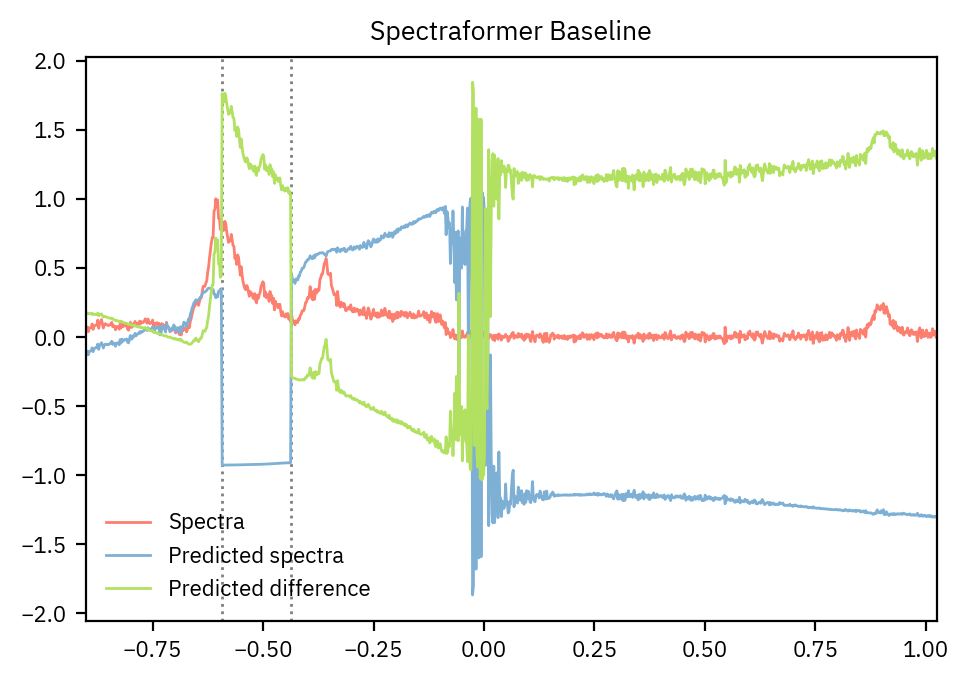

In [42]:
fig, ax = plot_results(spectraformer_predictions)
ax.set_title('Spectraformer Baseline')

### Training SpectraFormer

#### Model Init

In [4]:
import ml_confs
from flax.training import train_state

class TrainState(train_state.TrainState):
    model_confs: dict
    opt_confs: dict

model_confs = ml_confs.from_dict({
    'embedding_dim': 32,
    'num_heads': 4,
    'num_layers': 4,
})

opt_confs = ml_confs.from_dict({
    'learning_rate': 1e-4,
})

model = SpectraFormer(**model_confs)

# RNG Keys
root_key = jax.random.key(seed=0)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

# Model Initialization
variables = model.init(params_key, dummy_example['masked_spectra'][0], dummy_example['wave_number'], dummy_example['mask'], training = False)

In [5]:
state = TrainState.create(
    apply_fn=jax.jit(model.apply, static_argnames=('training', 'capture_intermediates')),
    params=variables['params'],
    tx=optax.adam(**opt_confs),
    model_confs=model_confs.to_dict(),
    opt_confs=opt_confs.to_dict()
)

In [6]:
import orbax.checkpoint as ocp
from pathlib import Path
# Checkpointing
tag = 'spectraformer:baseline'
ckpt_path = Path('../checkpoints/').resolve()

ckpt_options = ocp.CheckpointManagerOptions(max_to_keep=5)
ckpt_manager = ocp.CheckpointManager(ckpt_path / tag, options=ckpt_options)

### A proper training loop

In [7]:
from spectraformer.train import train_step
from clu import metric_writers, periodic_actions

#logging.set_verbosity(logging.INFO)
train_confs = ml_confs.from_dict({
    'num_epochs': 200,
    'batch_size': 32,
})
log_path = Path('../logs').resolve()


writer = metric_writers.create_default_writer(log_path / tag)
report_hook = periodic_actions.ReportProgress(writer=writer, every_steps=1, every_secs=None)

for epoch in range(train_confs.num_epochs):
    data_loader = batch_sampler(train_ds, batch_size=train_confs.batch_size, rng_seed = epoch, shuffle = True)
    for batch in data_loader:
        state, loss = train_step(state, batch, dropout_key)
        report_hook(state.step)
    writer.write_scalars(state.step, {'train/loss': loss.item()})
ckpt_manager.save(state.step, args=ocp.args.StandardSave(state))
ckpt_manager.wait_until_finished()

2024-02-21 18:51:30.602525: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-21 18:51:30.602557: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-21 18:51:30.603542: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-21 18:51:31.325160: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
INFO:absl:Setting work unit notes: 9.4 steps/s
INFO:absl:[2] steps_per_sec=9.398545265197754
INFO:absl:[2] uptime=7.67354
INFO:absl:Setting work unit notes: 2.6 steps/s
INFO:absl:[3] steps_per_sec=2.564293384552002
INFO:absl:[3] uptime=7.799

KeyboardInterrupt: 

In [12]:
import matplotlib.pyplot as plt

def plot_intermediates(batch, state):
    wave_number = batch['wave_number'] * 800 + 2000
    out, intermediates = state.apply_fn({'params': state.params}, batch['masked_spectra'], batch['wave_number'], attn_mask, training = False, capture_intermediates=True)
    intermediates = intermediates['intermediates']
    emb_counts = intermediates['LinearProjection_0']['__call__'][0]
    emb_wave_number = intermediates['LinearProjection_1']['__call__'][0]
    embedding = emb_counts + emb_wave_number

    EncoderBlock_0 = intermediates['TransformerEncoderLayer_0']['__call__'][0]
    EncoderBlock_1 = intermediates['TransformerEncoderLayer_1']['__call__'][0]
    EncoderBlock_2 = intermediates['TransformerEncoderLayer_2']['__call__'][0]


    fig, ax = plt.subplots(3, 3, figsize = (15, 15))
    ax[0, 0].plot(wave_number,np.squeeze(emb_counts))
    ax[0, 0].set_title('Counts embedding')
    ax[0, 0].margins(x= 0)
    ax[0, 1].plot(wave_number, np.squeeze(emb_wave_number))
    ax[0, 1].set_title('Wave number embedding')
    ax[0, 1].margins(x= 0)
    ax[0, 2].plot(wave_number, np.squeeze(embedding))
    ax[0, 2].set_title('Summed embedding')
    ax[0, 2].margins(x= 0)
    ax[1, 0].plot(wave_number, np.squeeze(EncoderBlock_0))
    ax[1, 0].set_title('Encoder block 0')
    ax[1, 0].margins(x= 0)
    ax[1, 1].plot(wave_number, np.squeeze(EncoderBlock_1))
    ax[1, 1].set_title('Encoder block 1')
    ax[1, 1].margins(x= 0)
    ax[1, 2].plot(wave_number, np.squeeze(EncoderBlock_2))
    ax[1, 2].set_title('Encoder block 2')
    ax[1, 2].margins(x= 0)
    ax[2, 0].plot(wave_number, np.squeeze(batch['spectra']), label = 'Target')
    ax[2, 0].plot(wave_number, np.squeeze(out), label = 'Output')
    ax[2, 0].axvline(x = mask_window[0], color = 'k', linestyle = '--', alpha=0.5)
    ax[2, 0].axvline(x = mask_window[1], color = 'k', linestyle = '--', alpha=0.5)
    ax[2, 0].legend(frameon = False)
    ax[2, 0].set_title('Output')
    ax[2, 0].margins(x= 0)
    plt.show()


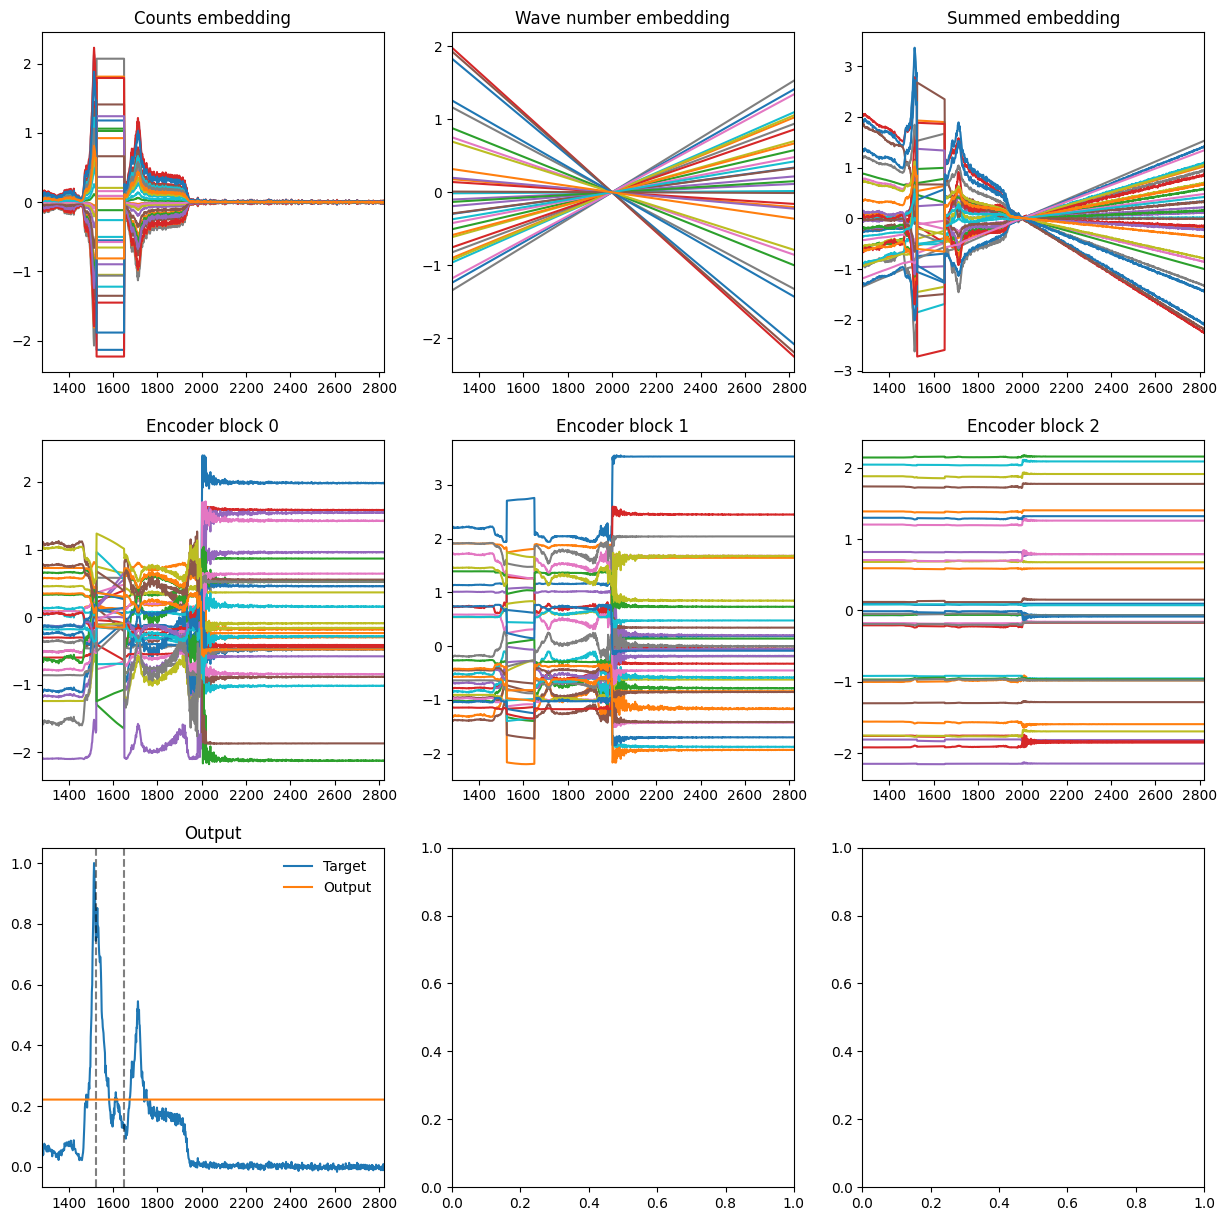

In [13]:
plot_intermediates(test_batch, state)

In [150]:
for epoch in tqdm(range(n_epochs)):
    train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = 32, shuffle = True, drop_last = True, rng_seed = epoch)
    for batch in train_iter:
        state, _loss = train_step(state, batch, dropout_key)
        train_loss.append(_loss.item())

  0%|          | 0/150 [00:00<?, ?it/s]

100%|██████████| 150/150 [03:12<00:00,  1.29s/it]


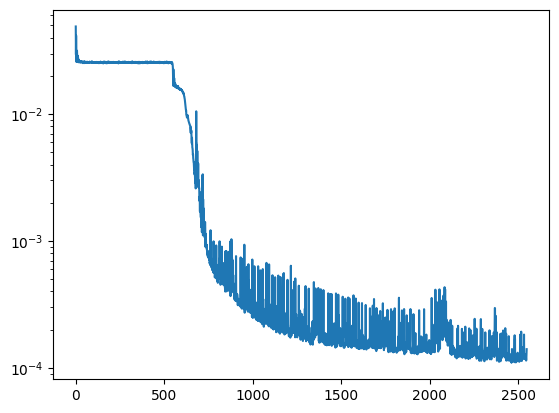

In [151]:
import matplotlib.pyplot as plt
plt.plot(train_loss)
plt.yscale('log')

In [20]:
def predict(apply_fn, params, spectra, wave_number):
    import pandas as pd
    predicted_SiC = apply_fn(params, spectra, wave_number, attn_mask, training = False)
    pred_Graphene = spectra - predicted_SiC
    res = {k: v[:, 0] for k, v in {'Predicted SiC': predicted_SiC, 'Diff': pred_Graphene, 'Original': spectra, 'Wave number': wave_number}.items()}
    return pd.DataFrame(res)

In [21]:
result = predict(state.apply_fn, {'params': state.params}, dummy_batch['masked_spectra'][0], dummy_batch['wave_number'])

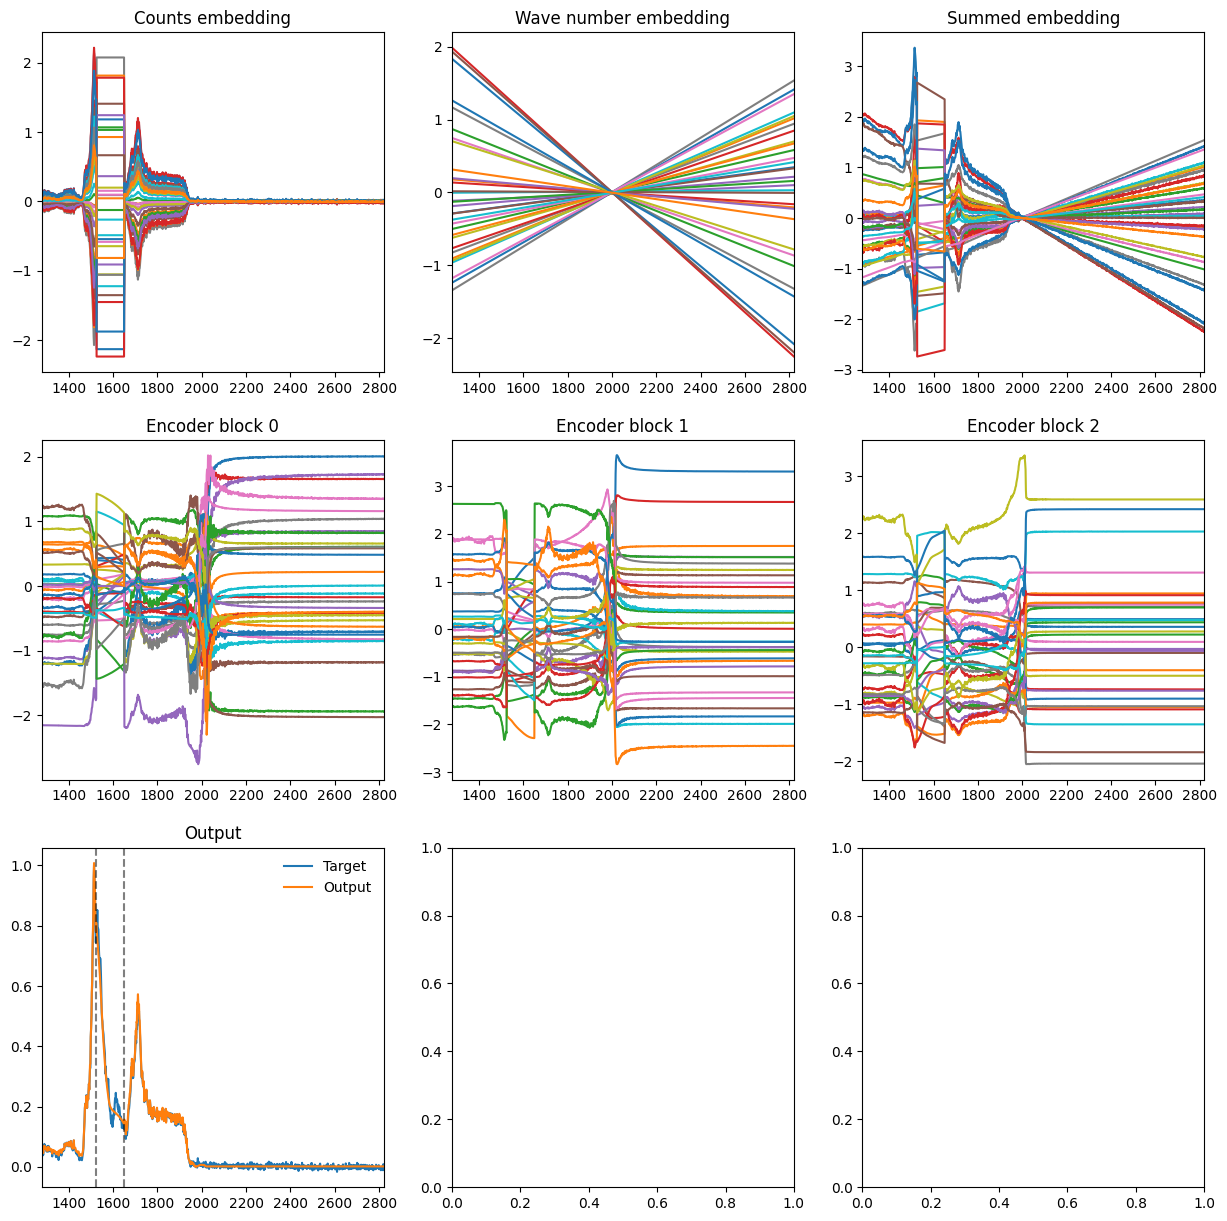

In [22]:
plot_intermediates(test_batch, state)

<Axes: xlabel='Wave number'>

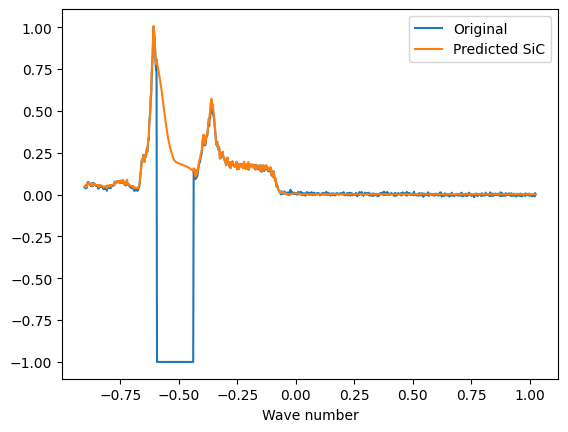

In [23]:
result.plot(x="Wave number", y=["Original", "Predicted SiC"])

In [19]:
from pathlib import Path
import orbax.checkpoint as ocp
checkpointer = ocp.StandardCheckpointer()

ckpt_dir = Path('../checkpoints/SpectraFormer').resolve()
state = checkpointer.restore(ckpt_dir / '20Feb24', state)
# checkpointer.save(ckpt_dir / '20Feb24', state)

In [9]:
from time import perf_counter

# Measure throughput at different batch sizes
batch_sizes = [8, 16, 32, 64, 128, 256]

for batch_size in batch_sizes:
    train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = batch_size, shuffle = True, drop_last = True)
    rng = jax.random.PRNGKey(0)
    rng, init_rng = jax.random.split(rng)
    batch = next(train_iter)
    variables = model.init(init_rng, counts = batch['masked_spectra'][0], wave_number = batch['wave_number'][0], training = False)
    # Warmup
    apply_fn = jax.jit(model.apply, static_argnames='training')
    apply_fn(variables, batch['masked_spectra'], batch['wave_number'], training=True, rngs = {'dropout': rng})
    
    # Measure throughput
    times = []
    for batch in train_iter:
        _dt = perf_counter()
        out = apply_fn(variables, batch['masked_spectra'], batch['wave_number'], training=True, rngs = {'dropout': rng})
        _dt = perf_counter() - _dt
        times.append(_dt)
    times = np.array(times)
    print(f"Batch size: {batch_size}, throughput: {batch_size / times.mean():.0f} samples/s")

Batch size: 8, throughput: 18170 samples/s
Batch size: 16, throughput: 29596 samples/s
Batch size: 32, throughput: 17774 samples/s
Batch size: 64, throughput: 16471 samples/s
Batch size: 128, throughput: 13481 samples/s
Batch size: 256, throughput: 19556 samples/s
